# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)


# Dataset Path & Parameters (MATCH TRAINING)

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/malware_project/final_dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 29

print("Dataset:", DATASET_PATH)
print("IMG_SIZE:", IMG_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)


Dataset: /content/drive/MyDrive/malware_project/final_dataset
IMG_SIZE: 224
NUM_CLASSES: 29


# Validation/Test Generator

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
    subset="validation",
    shuffle=False
)

y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

print("✔ Test data ready")
print("Classes:", len(class_names))


Found 3830 images belonging to 29 classes.
✔ Test data ready
Classes: 29


# Load MODELS

In [ ]:
models = {
    "Custom CNN": load_model(
        "/content/drive/MyDrive/malware_project/models/baseline_cnn.h5"
    ),

    "MobileNetV2": load_model(
        "/content/drive/MyDrive/malware_project/models/mobilenetv2_finetuned.h5"
    ),

    "Vision Transformer (ViT)": load_model(
        "/content/drive/MyDrive/malware_project/models/vit_final.keras"
    )
}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 104 variables whereas the saved optimizer has 206 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Evaluation Function (MULTI-CLASS)

In [ ]:
def evaluate_model(model, test_data):
    y_prob = model.predict(test_data)
    y_pred = np.argmax(y_prob, axis=1)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1-score": f1_score(y_true, y_pred, average="macro"),
        "y_pred": y_pred,
        "y_prob": y_prob
    }


# Run Evaluation

In [ ]:
results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    results[name] = evaluate_model(model, test_data)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Evaluating Custom CNN...
120/120 ━━━━━━━━━━━━━━━━━━━━ 1667s 14s/step
Evaluating MobileNetV2...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


120/120 ━━━━━━━━━━━━━━━━━━━━ 38s 214ms/step
Evaluating Vision Transformer (ViT)...
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Metrics Comparison Table (REPORT TABLE)

In [ ]:
metrics_df = pd.DataFrame({
    model: {
        "Accuracy": res["Accuracy"],
        "Precision (Macro)": res["Precision"],
        "Recall (Macro)": res["Recall"],
        "F1-score (Macro)": res["F1-score"]
    }
    for model, res in results.items()
}).T

metrics_df


,Accuracy,Precision (Macro),Recall (Macro),F1-score (Macro)
Custom CNN,0.727937,0.589691,0.802355,0.638740
MobileNetV2,0.970757,0.901312,0.928302,0.913311
Vision Transformer (ViT),0.523499,0.503206,0.731108,0.544724


# Confusion Matrix (FINAL MODEL ONLY)

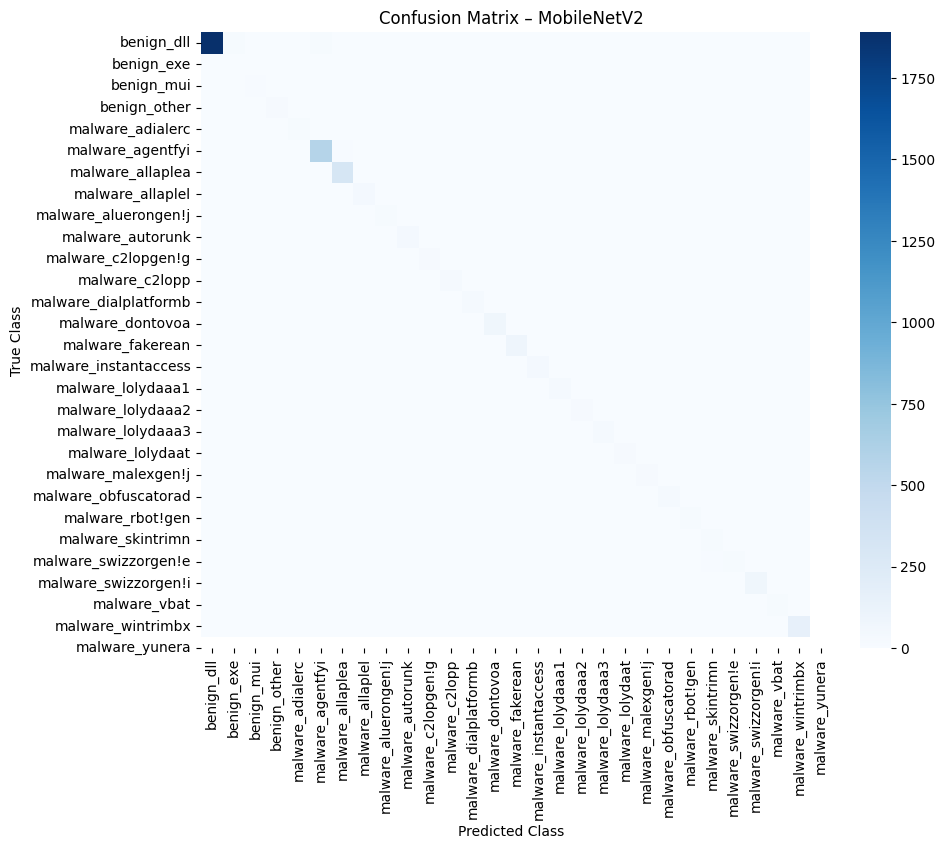

In [ ]:
# Confusion Matrix (FINAL BEST MODEL)

BEST_MODEL = "MobileNetV2"
best_res = results[BEST_MODEL]

cm = confusion_matrix(y_true, best_res["y_pred"])

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)
plt.title(f"Confusion Matrix – {BEST_MODEL}")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()


# ROC–AUC (MACRO, MULTI-CLASS)

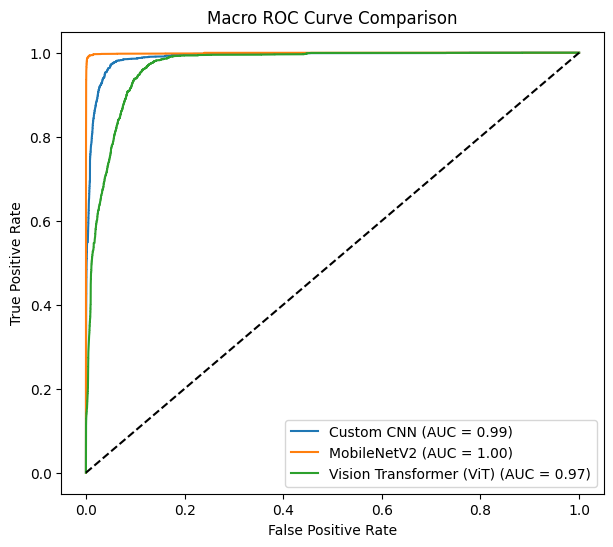

In [ ]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(7,6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(
        y_true_bin.ravel(),
        res["y_prob"].ravel()
    )
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro ROC Curve Comparison")
plt.legend()
plt.show()


# Performance Bar Chart

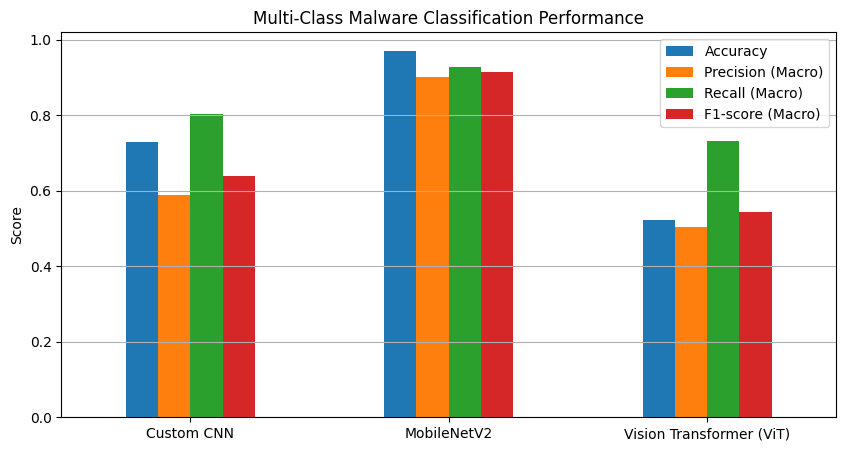

In [ ]:
metrics_df.plot(kind="bar", figsize=(10,5))
plt.title("Multi-Class Malware Classification Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()
